In [ ]:
pip install qiskit qiskit-aer quimb qiskit-quimb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.7/192.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.4 MB/s eta 0:00:00


In [ ]:
from qiskit import qasm, qasm2,qasm3, transpile
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
# from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import *

import numpy as np
from matplotlib import pyplot as plt
from qiskit.visualization import plot_histogram
from google.colab import files
import networkx as nx
# from qiskit_quimb import quimb_circuit
from qiskit_quimb import *
import quimb.tensor as qtn

In [ ]:
data = files.upload()

Saving P1_little_peak.qasm to P1_little_peak.qasm
Saving P2_swift_rise.qasm to P2_swift_rise.qasm
Saving P3__sharp_peak.qasm to P3__sharp_peak.qasm
Saving P4_golden_mountain.qasm to P4_golden_mountain.qasm
Saving P5_granite_summit.qasm to P5_granite_summit.qasm
Saving P6_titan_pinnacle.qasm to P6_titan_pinnacle.qasm


In [ ]:
from qiskit.circuit.library import TGate, HGate, SGate, CXGate, RXGate, RZGate, RYGate
from qiskit.transpiler.passes import SolovayKitaev

In [ ]:
def split_circuit(circuit, start, end):
    nq = len(circuit.qubits)
    qc2 = QuantumCircuit(nq)
    for x in circuit[start:end]:
        qc2.append(x)
    return qc2

In [ ]:
shots = 1000
optimization_level = 3
backend = AerSimulator(method="extended_stabilizer")
circ = QuantumCircuit.from_qasm_file('P5_granite_summit.qasm')
# circ.measure_all()
circ = circ.decompose(reps=2)
compile = transpile(circ,backend=backend,optimization_level=3,approximation_degree=1.0)
# skd = SolovayKitaev(recursion_degree=1)
# basis_gates = [TGate(), SGate(), HGate(),CXGate(),RXGate, RZGate, RYGate]
# compile = skd(compile)
compile = transpile(circ,basis_gates=['u3', 'cx'],optimization_level=3,approximation_degree=1.0)
quimb_circ = quimb_circuit(compile)

# res = {}
# for b in quimb_circ.sample_gate_by_gate(100):
#   res[b] = res[b]+1
#   print(res)

In [ ]:
shots = 100
optimization_level = 3
backend = AerSimulator(method="matrix_product_state")
circ = QuantumCircuit.from_qasm_file('P5_granite_summit.qasm')
# circ.measure_all()
# circ = circ.decompose(reps=3)
# compile = transpile(circ,backend=backend,optimization_level=3,approximation_degree=1.0)
compile = transpile(circ,basis_gates=['u3', 'cx'],optimization_level=3,approximation_degree=1.0)
quimb_circ = quimb_circuit(compile)
quimb_clist = quimb_gates(compile)

In [ ]:
import torch

def to_backend(x):
    return torch.tensor(x, dtype=torch.complex64, device="cuda")

In [ ]:
circ = qtn.CircuitMPS(
    N=48,
    gate_opts=dict(
        contract="nonlocal",
        method="dm",
        max_bond=2048,
        cutoff=5e-4,
    ),
    to_backend=to_backend,
)
circ.apply_gates(quimb_clist,progbar=True)
a = circ.sample(1000)

max_bond=2048, error~=1:  37%|###7      | 2075/5552 [1:33:47<2:37:09,  2.71s/it]


_LinAlgError: linalg.eigh: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated eigenvalues (error code: 1388).

In [ ]:
compile.draw(fold=200)

global phase: 5.909
        ┌────────────────────────────┐       ┌───────────────────┐       ┌────────────────────────────┐            ┌───────────────────┐             ┌────────────────────────────┐      »
 q_0: ──┤ U3(2.0058,-0.88174,1.7983) ├───■───┤ U3(2.4726,0,-π/2) ├───■───┤ U3(0.10367,2.4243,-3.1107) ├────────■───┤ U3(2.1209,0,-π/2) ├────────■────┤ U3(1.6629,0.63981,-1.4072) ├───■──»
        ├────────────────────────────┤ ┌─┴─┐┌┴───────────────────┴┐┌─┴─┐ ├────────────────────────────┤        │   └──┬──────────────┬─┘        │    ├────────────────────────────┤ ┌─┴─┐»
 q_1: ──┤ U3(2.3822,-0.84604,3.0316) ├─┤ X ├┤ U3(π/2,-π/2,2.4663) ├┤ X ├─┤ U3(2.4074,-2.4737,0.75516) ├───■────┼──────┤ U3(3,0,-π/2) ├─────■────┼────┤ U3(1.4387,-1.9105,-2.2262) ├─┤ X ├»
        └┬──────────────────────────┬┘ └───┘└┬───────────────────┬┘└───┘┌┴────────────────────────────┤ ┌─┴─┐  │  ┌───┴──────────────┴──┐┌─┴─┐  │    ├───────────────────────────┬┘ └───┘»
 q_2: ───┤ U3(2.0069,-1.1891,2.942) ├────■───┤ U3(3.0502,0,-π/2) ├───■──┤ U3(1.4263,0.14541,0.075769) ├─┤ X ├──┼──┤ U3(π/2,-π/2,2.7558) ├┤ X ├──┼────┤ U3(1.7177,1.0935,-1.7245) ├────■──»
         ├──────────────────────────┤  ┌─┴─┐ ├───────────────────┴┐┌─┴─┐└┬────────────────────────────┤ └───┘  │  └┬───────────────────┬┘└───┘  │    ├───────────────────────────┤  ┌─┴─┐»
 q_3: ───┤ U3(3.0433,-1.4827,3.005) ├──┤ X ├─┤ U3(π/2,-π/2,1.702) ├┤ X ├─┤ U3(1.0956,-0.92961,1.4905) ├───■────┼───┤ U3(2.9981,0,-π/2) ├───■────┼────┤ U3(1.5075,0.48028,1.0101) ├──┤ X ├»
        ┌┴──────────────────────────┴┐ └───┘ ├───────────────────┬┘└───┘ ├────────────────────────────┤ ┌─┴─┐  │  ┌┴───────────────────┴┐┌─┴─┐  │    ├───────────────────────────┤  └───┘»
 q_4: ──┤ U3(1.4531,2.5221,-0.71398) ├───■───┤ U3(2.9712,0,-π/2) ├───■───┤ U3(2.3283,-1.5324,0.55563) ├─┤ X ├──┼──┤ U3(π/2,-π/2,2.6391) ├┤ X ├──┼────┤ U3(2.8101,-2.6925,3.0766) ├────■──»
       ┌┴────────────────────────────┤ ┌─┴─┐┌┴───────────────────┴┐┌─┴─┐ └┬──────────────────────────┬┘ └───┘  │  └┬───────────────────┬┘└───┘  │    └┬──────────────────────────┤  ┌─┴─┐»
 q_5: ─┤ U3(1.2661,0.89239,-0.70054) ├─┤ X ├┤ U3(π/2,-π/2,3.0228) ├┤ X ├──┤ U3(1.675,-1.4798,-2.131) ├────■────┼───┤ U3(3.0286,0,-π/2) ├───■────┼─────┤ U3(1.5779,1.5911,1.2588) ├──┤ X ├»
       ├─────────────────────────────┤ └───┘└┬───────────────────┬┘└───┘  └┬────────────────────────┬┘  ┌─┴─┐  │  ┌┴───────────────────┴┐┌─┴─┐  │     ├──────────────────────────┤  └───┘»
 q_6: ─┤ U3(3.0786,-0.50604,-1.2483) ├───■───┤ U3(1.9707,0,-π/2) ├───■─────┤ U3(2.1483,2.316,-2.31) ├───┤ X ├──┼──┤ U3(π/2,-π/2,2.1244) ├┤ X ├──┼─────┤ U3(1.1197,2.6337,2.0877) ├────■──»
       ├─────────────────────────────┴┐┌─┴─┐┌┴───────────────────┴┐┌─┴─┐ ┌─┴────────────────────────┴─┐ └───┘  │  └┬───────────────────┬┘└───┘  │    ┌┴──────────────────────────┤  ┌─┴─┐»
 q_7: ─┤ U3(1.5726,-0.0029132,1.1774) ├┤ X ├┤ U3(π/2,-π/2,2.8438) ├┤ X ├─┤ U3(0.92626,-1.8836,1.5457) ├───■────┼───┤ U3(2.1677,0,-π/2) ├───■────┼────┤ U3(1.6163,-1.5074,1.8553) ├──┤ X ├»
       ├─────────────────────────────┬┘└───┘└┬───────────────────┬┘└───┘ ├───────────────────────────┬┘ ┌─┴─┐  │  ┌┴───────────────────┴┐┌─┴─┐  │    ├───────────────────────────┴┐ └───┘»
 q_8: ─┤ U3(1.2607,-1.5085,-0.66955) ├───■───┤ U3(2.0903,0,-π/2) ├───■───┤ U3(1.7235,1.4122,-2.1567) ├──┤ X ├──┼──┤ U3(π/2,-π/2,2.8659) ├┤ X ├──┼────┤ U3(1.6429,-1.6476,-1.1424) ├───■──»
       └┬───────────────────────────┬┘ ┌─┴─┐┌┴───────────────────┴┐┌─┴─┐┌┴───────────────────────────┴┐ └───┘  │  └┬───────────────────┬┘└───┘  │    └┬─────────────────────────┬─┘ ┌─┴─┐»
 q_9: ──┤ U3(1.6701,0.01154,2.0862) ├──┤ X ├┤ U3(π/2,-π/2,3.0349) ├┤ X ├┤ U3(0.72493,0.66782,-1.1266) ├───■────┼───┤ U3(3.1264,0,-π/2) ├───■────┼─────┤ U3(1.015,0.4435,-2.784) ├───┤ X ├»
        └─┬───────────────────────┬─┘  └───┘└┬───────────────────┬┘└───┘└┬───────────────────────────┬┘ ┌─┴─┐  │  ┌┴───────────────────┴┐┌─┴─┐  │    ┌┴─────────────────────────┴─┐ └───┘»
q_10: ────┤ U3(1.599,3.13,2.0148) ├──────■───┤ U3(2.2

In [ ]:
def split_circuit(circuit, start, end):
    nq = len(circuit.qubits)
    qc2 = QuantumCircuit(nq)
    for x in circuit[start:end]:
        qc2.append(x[0], x[1])
    return qc2

In [ ]:
def parse_qasm_for_2q_gates(file_path):
    edges = set()
    qubits = set()

    # Supported 2-qubit gates
    two_qubit_gates = {'cx', 'cz', 'swap'}

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()

            if not line or line.startswith('//') or line.startswith('OPENQASM') or line.startswith('include'):
                continue

            parts = line.split()
            if len(parts) == 2 and parts[0] in two_qubit_gates:
                gate = parts[0]
                args = parts[1].replace(';', '')
                q1, q2 = [int(arg.split('[')[1].rstrip(']')) for arg in args.split(',')]

                # Record both directions (symmetric graph)
                edges.add(tuple(sorted((q1, q2))))
                qubits.update([q1, q2])

    return edges, sorted(qubits)

def create_adjacency_matrix(edges, qubits):
    size = max(qubits) + 1
    matrix = np.zeros((size, size), dtype=int)

    for q1, q2 in edges:
        matrix[q1][q2] = 1
        matrix[q2][q1] = 1  # symmetric

    return matrix

def visualize_graph(matrix):
    G = nx.Graph()
    size = len(matrix)

    for i in range(size):
        G.add_node(i)

    for i in range(size):
        for j in range(i + 1, size):
            if matrix[i][j]:
                G.add_edge(i, j)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, edge_color='gray', font_weight='bold')
    plt.title("2-Qubit Gate Connectivity Graph")
    plt.show()

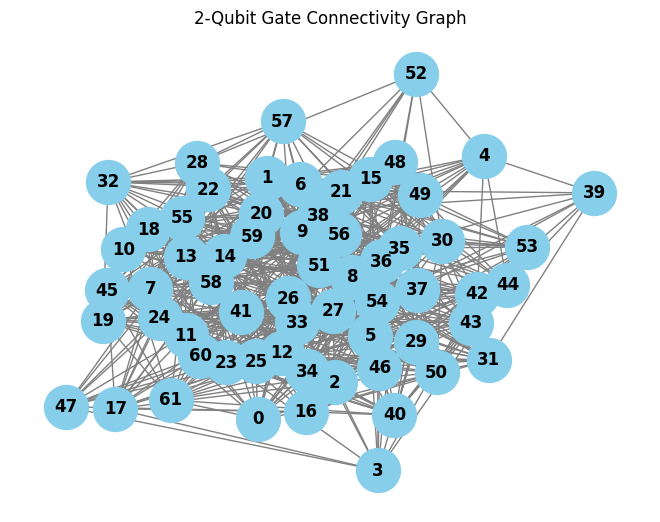

In [ ]:
qasm_path = "P6_titan_pinnacle.qasm"  # Replace with your actual file path
edges, qubits = parse_qasm_for_2q_gates(qasm_path)
matrix = create_adjacency_matrix(edges, qubits)
visualize_graph(matrix)

In [ ]:
shots = 1000
optimization_level = 3
backend = AerSimulator(method="tensor_network")
# print(backend._basis_gates())
circ = QuantumCircuit.from_qasm_file('P4_golden_mountain.qasm')
circ.measure_all()
circ = circ.decompose(reps=3)
# pm = generate_preset_pass_manager(optimization_level,
#                                   backend=backend)
compile = transpile(circ,backend=backend,optimization_level=3,approximation_degree=1.0)
# circ.draw('m')
# subcircs = []
# m = circ.count_ops()
# for x in range(m/500):
#   subcircs.append()

CircuitTooWideForTarget: 'Number of qubits (48) in circuit-162 is greater than maximum (29) in the coupling_map'

In [ ]:
circs = []
for x in range(2):
    circs.append(transpile(circ,backend=backend,optimization_level=3,approximation_degree=.8,seed_transpiler=x))
    print("circ", x ,"down")

print("transpile complete")
circs[0].draw()

circ 0 down
circ 1 down
transpile complete


global phase: 4.7276
             ┌───┐      ┌───────────┐                             »
    q_0: ────┤ X ├──────┤ P(-3.185) ├─────────────────────────────»
         ┌───┴───┴───┐  └───────────┘                             »
    q_1: ┤ P(2.8227) ├────────────────────────────────────■───────»
         ├───────────┴┐     ┌────┐     ┌─────────┐      ┌─┴─┐     »
    q_2: ┤ P(-2.2594) ├─────┤ √X ├─────┤ P(-π/2) ├──────┤ X ├─────»
         └───┬───┬────┘┌────┴────┴───┐ └─────────┘      └───┘     »
    q_3: ────┤ X ├─────┤ Rz(-1.5582) ├────────────────────────────»
             ├───┤     └─────────────┘                            »
    q_4: ────┤ X ├────────────────────────────────────────────────»
         ┌───┴───┴────┐     ┌────┐    ┌────────────┐    ┌────┐    »
    q_5: ┤ P(-2.8099) ├─────┤ √X ├────┤ P(-1.6604) ├────┤ √X ├────»
         ├───────────┬┘     └────┘    └────────────┘   ┌┴────┴┐   »
    q_6: ┤ P(2.3994) ├─────────────────────────────────┤0     ├───»
         └───┬────┬──┘  ┌───────────┐     ┌────┐       │  Ecr │   »
    q_7: ────┤ √X ├─────┤ P(1.5674) ├─────┤ √X ├───────┤1     ├───»
             ├───┬┘     ├───────────┴┐    └────┘       └──────┘   »
    q_8: ────┤ X ├──────┤ Rz(2.9748) ├────────────────────────────»
             ├───┴┐     ├────────────┤    ┌────┐    ┌───────────┐ »
    q_9: ────┤ √X ├─────┤ P(-1.5973) ├────┤ √X ├────┤ P(-2.921) ├─»
         ┌───┴────┴───┐ └───┬────┬───┘┌───┴────┴───┐└───┬────┬──┘ »
   q_10: ┤ P(-1.4183) ├─────┤ √X ├────┤ P(-1.5893) ├────┤ √X ├────»
         └───┬────┬───┘ ┌───┴────┴───┐└───┬────┬───┘┌───┴────┴───┐»
   q_11: ────┤ √X ├─────┤ P(-1.1655) ├────┤ √X ├────┤ P(-2.9938) ├»
             ├────┤     └─┬───────┬──┘    └────┘    └────────────┘»
   q_12: ────┤ √X ├───────┤ P(-π) ├───────────────────────────────»
         ┌───┴────┴───┐   └─┬────┬┘   ┌────────────┐    ┌────┐    »
   q_13: ┤ P(-2.6464) ├─────┤ √X ├────┤ P(-1.3788) ├────┤ √X ├────»
         └───┬───┬────┘┌────┴────┴───┐└────────────┘    └────┘    »
   q_14: ────┤ X ├─────┤ Rz(-1.7102) ├────────────────────────────»
             ├───┴┐    └─────────────┘                            »
   q_15: ────┤ √X ├───────────────────────────────────────────────»
         ┌───┴────┴──┐      ┌────┐    ┌────────────┐    ┌────┐    »
   q_16: ┤ P(3.1149) ├──────┤ √X ├────┤ P(-2.5349) ├────┤ √X ├────»
         └───┬───┬───┘      └────┘    └────────────┘    └────┘    »
   q_17: ────┤ X ├────────────────────────────────────────────────»
             ├───┤     ┌─────────────┐                            »
   q_18: ────┤ X ├─────┤ Rz(-3.0456) ├────────────────────────────»
             ├───┤     └─────────────┘                            »
   q_19: ────┤ X ├────────────────────────────────────────────────»
         ┌───┴───┴───┐      ┌────┐    ┌────────────┐    ┌────┐    »
   q_20: ┤ P(2.1174) ├──────┤ √X ├────┤ P(-1.2331) ├────┤ √X ├────»
         └───┬────┬──┘  ┌───┴────┴───┐└───┬────┬───┘┌───┴────┴──┐ »
   q_21: ────┤ √X ├─────┤ P(-2.0702) ├────┤ √X ├────┤ P(-2.247) ├─»
         ┌───┴────┴──┐  └───┬────┬───┘┌───┴────┴───┐└───┬────┬──┘ »
   q_22: ┤ P(2.5015) ├──────┤ √X ├────┤ P(-2.1899) ├────┤ √X ├────»
         └───┬────┬──┘  ┌───┴────┴───┐└───┬────┬───┘┌───┴────┴───┐»
   q_23: ────┤ √X ├─────┤ P(-1.3872) ├────┤ √X ├────┤ P(-1.9635) ├»
             ├───┬┘     ├───────────┬┘    └────┘    └────────────┘»
   q_24: ────┤ X ├──────┤ Rz(3.031) ├─────────────────────────────»
         ┌───┴───┴───┐  └───────────┘                             »
   q_25: ┤ P(3.8856) ├────────────────────────────────────────────»
         └───┬────┬──┘  ┌────────────┐    ┌────┐                  »
   q_26: ────┤ √X ├─────┤ P(-1.9552) ├────┤ √X ├──────────■───────»
             ├───┬┘     └────────────┘    └────┘        ┌─┴─┐     »
   q_27: ────┤ X ├──────────────────────────────────────┤ X ├─────»
             ├───┤                                      ├───┤     »
   q_28: ────┤ X ├──────────────────────────■───────────┤ X ├─────»
           ┌─┴───┴──┐       ┌───┐  

In [ ]:
from collections import Counter
sum = Counter({})
for x in circs:
    print("starting run")
    job = backend.run(x,shots=shots)
    print("finished run")
    res = job.result()
    counts = Counter(res.get_counts())
    sum += counts
    print(dict(sum))
plot_histogram(dict(sum))

starting run
finished run


ERROR:  [Experiment 0] a circuit requires more memory than max_memory_mb.


QiskitError: 'ERROR:  [Experiment 0] a circuit requires more memory than max_memory_mb. ,  ERROR: a circuit requires more memory than max_memory_mb.'

In [ ]:

opts = {
    'use_cuTensorNet_autotuning': True
}
print("starting run")
job = backend.run(compile,shots=shots,**opts)
print("finished run")
res = job.result()
counts = Counter(res.get_counts())
plot_histogram(counts)